<center><h1>Last_First_HW5</h1></center>
<br>
<br>

Name: Madhulika Vikraman
<br>
Github Username: madhulikavikraman
<br>
USC ID: 2083047114

## 1. Decision Trees as Interpretable Models

Import packages

In [114]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 4.7/101.7 MB 28.4 MB/s eta 0:00:04
   ----- ---------------------------------- 13.6/101.7 MB 35.7 MB/s eta 0:00:03
   -------- ------------------------------- 21.5/101.7 MB 35.7 MB/s eta 0:00:03
   ----------- ---------------------------- 29.4/101.7 MB 35.8 MB/s eta 0:00:03
   -------------- ------------------------- 37.7/101.7 MB 36.9 MB/s eta 0:00:02
   ----------------- ---------------------- 45.4/101.7 MB 36.5 MB/s eta 0:00:02
   -------------------- ------------------- 53.0/101.7 MB 36.6 MB/s eta 0:00:02
   ----------------------- ---------------- 59.0/101.7 MB 35.8 MB/s eta 0:00:02
   -------------------------- ------------- 67.1/101.7 MB 35.9 MB/s eta 0:00:01
   ---------------------------- ----------- 72.9/101.7 MB 34.9 MB/s eta 0:00:01
   ------------------------------ --------- 77.6/101.7 MB 33.7 MB/s eta 0:00:01
   --------------------------------- ------ 84.4/1

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os
import math
from sklearn import tree
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics import hamming_loss, precision_score, recall_score, f1_score
from sklearn.tree import _tree
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

### (a) Obtain Data

Get the Accute Inamations Data Set

In [2]:
col_nmes = ["Temperature", "Nausea", "Lumbar", "Urine", "Micturition", "Urethra", "decision1", "decision2"]
multi_label_classification = ["No inflammation, No Nephritis", "No inflammation, Nephritis", "Inflammation, No Nephritis", "Inflammation, Nephritis"]
df = pd.read_csv("../data/diagnosis.data", sep="\t", encoding='utf-16', decimal=',', header=None)
df.columns = col_nmes
df.head()

,Temperature,Nausea,Lumbar,Urine,Micturition,Urethra,decision1,decision2
0,35.5,no,yes,no,no,no,no,no
1,35.9,no,no,yes,yes,yes,yes,no
2,35.9,no,yes,no,no,no,no,no
3,36.0,no,no,yes,yes,yes,yes,no
4,36.0,no,yes,no,no,no,no,no


### (b) Build a decision tree

C:\Users\madhu\AppData\Local\Temp\ipykernel_9228\1476858092.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"yes": 1, "no": 0}, inplace=True)


[Text(0.4, 0.9, 'Temperature <= 37.95\ngini = 0.493\nsamples = 120\nvalue = [[61, 59]\n[70, 50]]'),
 Text(0.2, 0.7, 'Lumbar <= 0.5\ngini = 0.222\nsamples = 60\nvalue = [[20, 40]\n[60, 0]]'),
 Text(0.30000000000000004, 0.8, 'True  '),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [[0, 40]\n[40, 0]]'),
 Text(0.3, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [[20, 0]\n[20, 0]]'),
 Text(0.6, 0.7, 'Lumbar <= 0.5\ngini = 0.355\nsamples = 60\nvalue = [[41, 19]\n[10, 50]]'),
 Text(0.5, 0.8, '  False'),
 Text(0.5, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [[10, 0]\n[10, 0]]'),
 Text(0.7, 0.5, 'Micturition <= 0.5\ngini = 0.236\nsamples = 50\nvalue = [[31, 19]\n[0, 50]]'),
 Text(0.6, 0.3, 'gini = 0.0\nsamples = 21\nvalue = [[21, 0]\n[0, 21]]'),
 Text(0.8, 0.3, 'Urine <= 0.5\ngini = 0.226\nsamples = 29\nvalue = [[10, 19]\n[0, 29]]'),
 Text(0.7, 0.1, 'gini = 0.0\nsamples = 10\nvalue = [[10, 0]\n[0, 10]]'),
 Text(0.9, 0.1, 'gini = 0.0\nsamples = 19\nvalue = [[0, 19]\n[0, 19]]')]

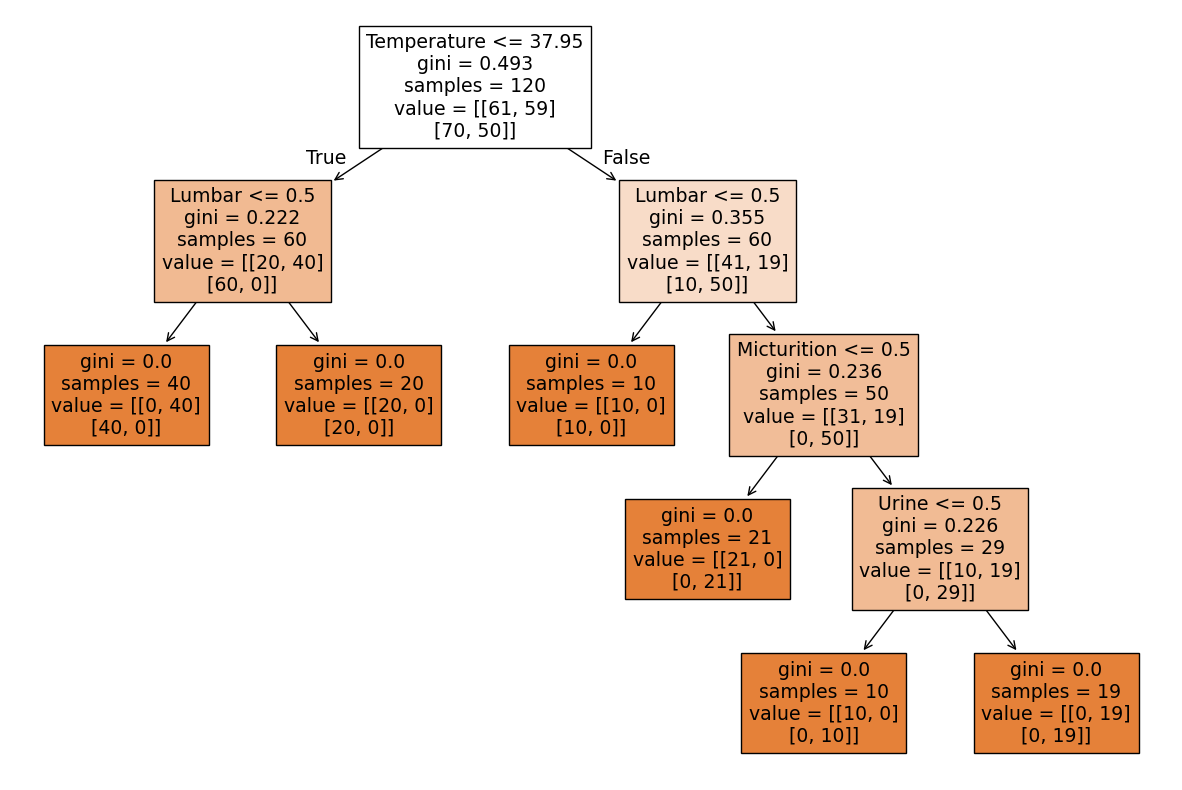

In [3]:
df.replace({"yes": 1, "no": 0}, inplace=True)
df = df.infer_objects(copy=False)
y = df[["decision1", "decision2"]]
X = df.drop(columns=["decision1", "decision2"])
dtree = tree.DecisionTreeClassifier()
dtree.fit(X, y)
plt.figure(figsize=(15,10))
tree.plot_tree(dtree, feature_names=X.columns, filled=True)

Using the label superset method to convert multi-label to multi-class dataset.

[Text(0.4, 0.9, 'Lumbar <= 0.5\ngini = 0.735\nsamples = 120\nvalue = [30.0, 31.0, 40.0, 19.0]\nclass = Inflammation, No Nephritis'),
 Text(0.2, 0.7, 'Temperature <= 38.95\ngini = 0.32\nsamples = 50\nvalue = [10, 0, 40, 0]\nclass = Inflammation, No Nephritis'),
 Text(0.30000000000000004, 0.8, 'True  '),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [0, 0, 40, 0]\nclass = Inflammation, No Nephritis'),
 Text(0.3, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [10, 0, 0, 0]\nclass = No inflammation, No Nephritis'),
 Text(0.6, 0.7, 'Temperature <= 37.95\ngini = 0.649\nsamples = 70\nvalue = [20, 31, 0, 19]\nclass = No inflammation, Nephritis'),
 Text(0.5, 0.8, '  False'),
 Text(0.5, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [20, 0, 0, 0]\nclass = No inflammation, No Nephritis'),
 Text(0.7, 0.5, 'Micturition <= 0.5\ngini = 0.471\nsamples = 50\nvalue = [0, 31, 0, 19]\nclass = No inflammation, Nephritis'),
 Text(0.6, 0.3, 'gini = 0.0\nsamples = 21\nvalue = [0, 21, 0, 0]\nclass = No inflammation, Ne

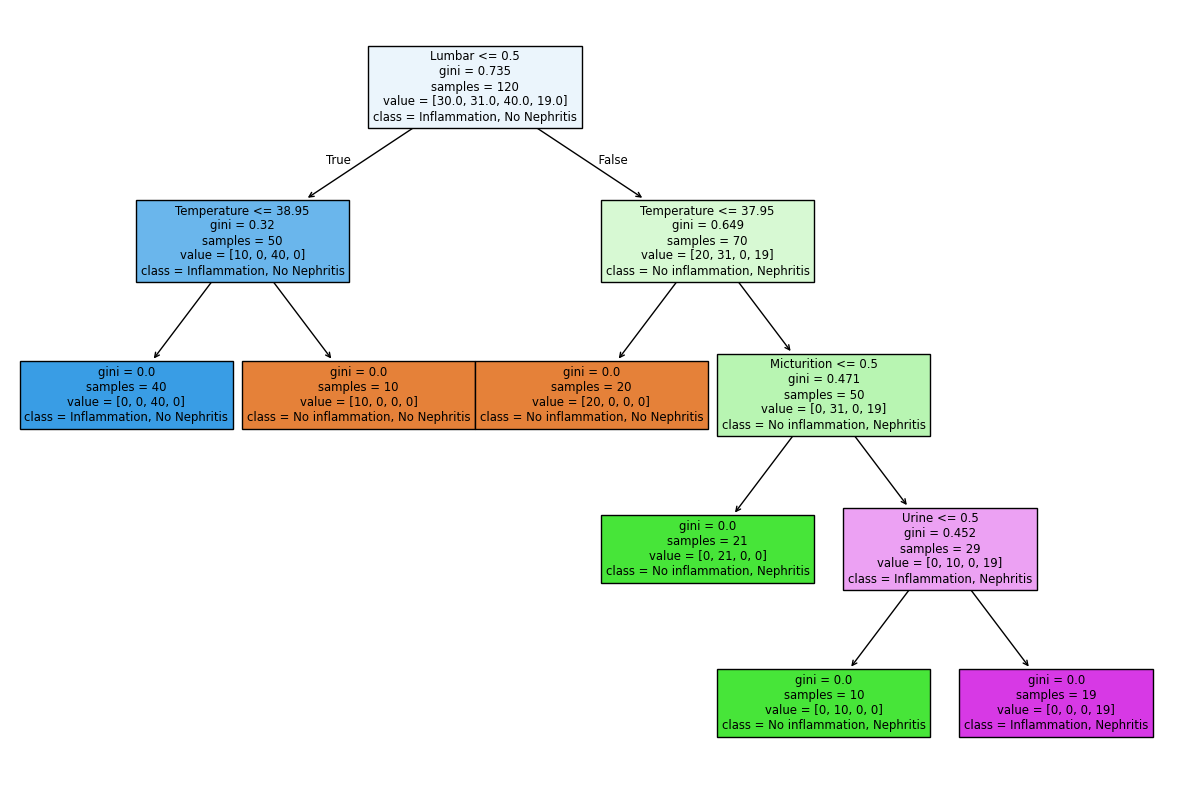

In [4]:
# clf = MultiOutputClassifier(dtree).fit(X, y)
y_label_superset = y.apply(lambda row: str(tuple(row)), axis=1)
dtree = tree.DecisionTreeClassifier()
dtree.fit(X, y_label_superset)
plt.figure(figsize=(15,10))
tree.plot_tree(dtree, feature_names=X.columns, class_names=multi_label_classification, filled=True)

### (c) Convert the decision rules

Code taken from :- https://www.kdnuggets.com/2017/05/simplifying-decision-tree-interpretation-decision-rules-python.html

In [5]:
def tree_to_code(tree, feature_names):
	tree_ = tree.tree_
	feature_name = [
		feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
		for i in tree_.feature
	]
	print("def tree({}):".format(", ".join(feature_names)))

	def recurse(node, depth):
		indent = "  " * depth
		if tree_.feature[node] != _tree.TREE_UNDEFINED:
			name = feature_name[node]
			threshold = tree_.threshold[node]
			print("{}if {} <= {}:".format(indent, name, threshold))
			recurse(tree_.children_left[node], depth + 1)
			print("{}else:  # if {} > {}".format(indent, name, threshold))
			recurse(tree_.children_right[node], depth + 1)
		else:
			print("{}return {}".format(indent, tree_.value[node]))

	recurse(0, 1)

In [6]:
tree_to_code(dtree, list(X.columns))

def tree(Temperature, Nausea, Lumbar, Urine, Micturition, Urethra):
  if Lumbar <= 0.5:
    if Temperature <= 38.95000076293945:
      return [[0. 0. 1. 0.]]
    else:  # if Temperature > 38.95000076293945
      return [[1. 0. 0. 0.]]
  else:  # if Lumbar > 0.5
    if Temperature <= 37.95000076293945:
      return [[1. 0. 0. 0.]]
    else:  # if Temperature > 37.95000076293945
      if Micturition <= 0.5:
        return [[0. 1. 0. 0.]]
      else:  # if Micturition > 0.5
        if Urine <= 0.5:
          return [[0. 1. 0. 0.]]
        else:  # if Urine > 0.5
          return [[0. 0. 0. 1.]]


### (d) Cost complexity pruning

In [7]:
X = df.iloc[:, 0 :6]
y = df.iloc[:, -2 :]
y = df[["decision1", "decision2"]]
X = df.drop(columns=["decision1", "decision2"])
dtree = tree.DecisionTreeClassifier()
path = dtree.cost_complexity_pruning_path(X, y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

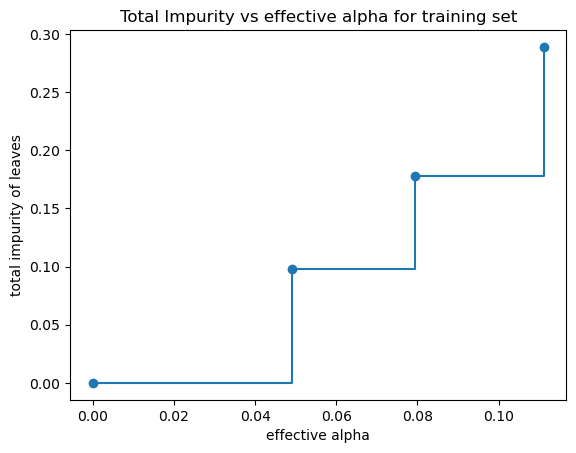

In [8]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

Best ccp alpha value:  0.0


[Text(0.4, 0.9, 'Temperature <= 37.95\ngini = 0.493\nsamples = 120\nvalue = [[61, 59]\n[70, 50]]'),
 Text(0.2, 0.7, 'Lumbar <= 0.5\ngini = 0.222\nsamples = 60\nvalue = [[20, 40]\n[60, 0]]'),
 Text(0.30000000000000004, 0.8, 'True  '),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [[0, 40]\n[40, 0]]'),
 Text(0.3, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [[20, 0]\n[20, 0]]'),
 Text(0.6, 0.7, 'Lumbar <= 0.5\ngini = 0.355\nsamples = 60\nvalue = [[41, 19]\n[10, 50]]'),
 Text(0.5, 0.8, '  False'),
 Text(0.5, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [[10, 0]\n[10, 0]]'),
 Text(0.7, 0.5, 'Micturition <= 0.5\ngini = 0.236\nsamples = 50\nvalue = [[31, 19]\n[0, 50]]'),
 Text(0.6, 0.3, 'gini = 0.0\nsamples = 21\nvalue = [[21, 0]\n[0, 21]]'),
 Text(0.8, 0.3, 'Urine <= 0.5\ngini = 0.226\nsamples = 29\nvalue = [[10, 19]\n[0, 29]]'),
 Text(0.7, 0.1, 'gini = 0.0\nsamples = 10\nvalue = [[10, 0]\n[0, 10]]'),
 Text(0.9, 0.1, 'gini = 0.0\nsamples = 19\nvalue = [[0, 19]\n[0, 19]]')]

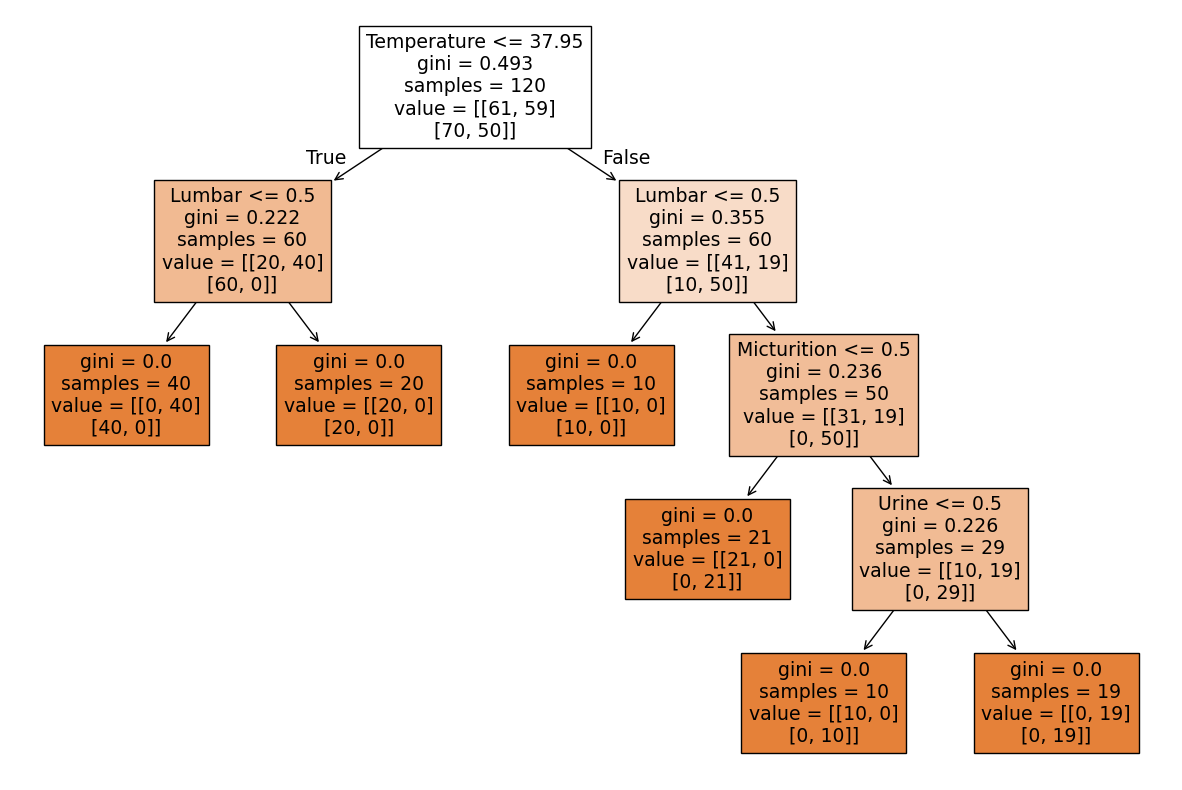

In [9]:
param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X, y)
best_alpha = grid_search.best_params_['ccp_alpha']
print("Best ccp alpha value: ", best_alpha)
clf_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha)
clf_pruned.fit(X, y)
plt.figure(figsize=(15,10))
tree.plot_tree(clf_pruned, feature_names=X.columns, class_names=multi_label_classification, filled=True)

In [10]:
tree_to_code(clf_pruned, list(X.columns))

def tree(Temperature, Nausea, Lumbar, Urine, Micturition, Urethra):
  if Temperature <= 37.95000076293945:
    if Lumbar <= 0.5:
      return [[0. 1.]
 [1. 0.]]
    else:  # if Lumbar > 0.5
      return [[1. 0.]
 [1. 0.]]
  else:  # if Temperature > 37.95000076293945
    if Lumbar <= 0.5:
      return [[1. 0.]
 [1. 0.]]
    else:  # if Lumbar > 0.5
      if Micturition <= 0.5:
        return [[1. 0.]
 [0. 1.]]
      else:  # if Micturition > 0.5
        if Urine <= 0.5:
          return [[1. 0.]
 [0. 1.]]
        else:  # if Urine > 0.5
          return [[0. 1.]
 [0. 1.]]


## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [53]:
df = pd.read_csv("../data/communities.data", header=None, na_values='?')
df_train = df.iloc[:1495, :]
df_test = df.iloc[1495:, :]
df.shape, df_train.shape, df_test.shape

((1994, 128), (1495, 128), (499, 128))

### (b) Missing values

In [54]:
col_names = []
with open("../data/communities.names", "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("@attribute"):
            parts = line.split()            
            col_name = parts[1]
            col_names.append(col_name)
df.columns = col_names
df_train.columns = col_names
df_test.columns = col_names
df.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [55]:
non_predictive = ["state", "county", "community", "communityname", "fold"]
df = df.drop(columns=non_predictive)
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(df)
df_imputed = pd.DataFrame(imp.transform(df), columns=df.columns)
df_train = df_train.drop(columns=non_predictive)
df_test = df_test.drop(columns=non_predictive)
imp_train = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_train.fit(df_train)
df_imputed_train = pd.DataFrame(imp_train.transform(df_train), columns=df_train.columns)
imp_test = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_test.fit(df_test)
df_imputed_test = pd.DataFrame(imp_test.transform(df_test), columns=df_test.columns)


### (c) Plot a correlation matrix

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
population,1.000000,-0.046148,0.231178,-0.300845,0.181603,0.156218,0.006368,0.130344,0.075596,-0.102006,...,0.713652,0.231897,0.270356,0.609147,0.595543,-0.061583,0.076527,0.466352,-0.035576,0.367157
householdsize,-0.046148,1.000000,-0.067109,-0.235907,0.201996,0.468659,0.520461,0.367338,0.295225,-0.612666,...,-0.015078,-0.004072,-0.051506,-0.032663,-0.007584,-0.006426,-0.000280,-0.094368,-0.054562,-0.034923
racepctblack,0.231178,-0.067109,1.000000,-0.794389,-0.106738,-0.066581,0.122338,0.153475,0.134068,0.052934,...,0.149758,0.095053,0.147023,0.122017,0.083179,-0.082660,0.010987,0.260793,0.022237,0.631264
racePctWhite,-0.300845,-0.235907,-0.794389,1.000000,-0.270266,-0.444166,-0.194015,-0.266852,-0.183804,0.136483,...,-0.131389,-0.337458,-0.215636,-0.109191,-0.114860,0.052940,-0.033209,-0.276234,-0.006323,-0.684770
racePctAsian,0.181603,0.201996,-0.106738,-0.270266,1.000000,0.266743,-0.025020,0.100727,0.052761,-0.272020,...,-0.001084,0.389944,0.296921,-0.017992,0.067745,0.032389,0.065424,0.101888,-0.011619,0.037622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LemasPctPolicOnPatr,-0.061583,-0.006426,-0.082660,0.052940,0.032389,0.024366,0.000652,0.013327,0.013687,0.005601,...,-0.067678,0.055734,0.023457,-0.115349,-0.089736,1.000000,0.007179,0.021153,-0.237240,-0.039002
LemasGangUnitDeploy,0.076527,-0.000280,0.010987,-0.033209,0.065424,0.025956,0.011271,0.005145,-0.001001,-0.042756,...,0.109830,-0.076634,-0.082946,0.078436,0.023349,0.007179,1.000000,-0.015712,-0.021100,0.055038
LemasPctOfficDrugUn,0.466352,-0.094368,0.260793,-0.276234,0.101888,0.125353,0.001301,0.117290,0.083180,-0.010168,...,0.299632,0.228084,0.206644,-0.052426,-0.062677,0.021153,-0.015712,1.000000,0.018649,0.348627
PolicBudgPerPop,-0.035576,-0.054562,0.022237,-0.006323,-0.011619,0.002234,-0.076589,-0.068575,-0.049876,0.076586,...,-0.113166,0.067199,0.080024,0.245532,0.259342,-0.237240,-0.021100,0.018649,1.000000,0.045466


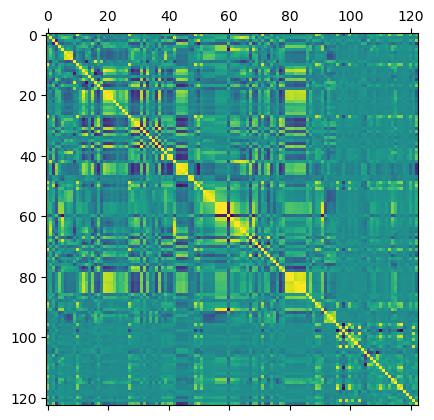

In [56]:
display(df_imputed.corr())
plt.matshow(df_imputed.corr())
plt.show()

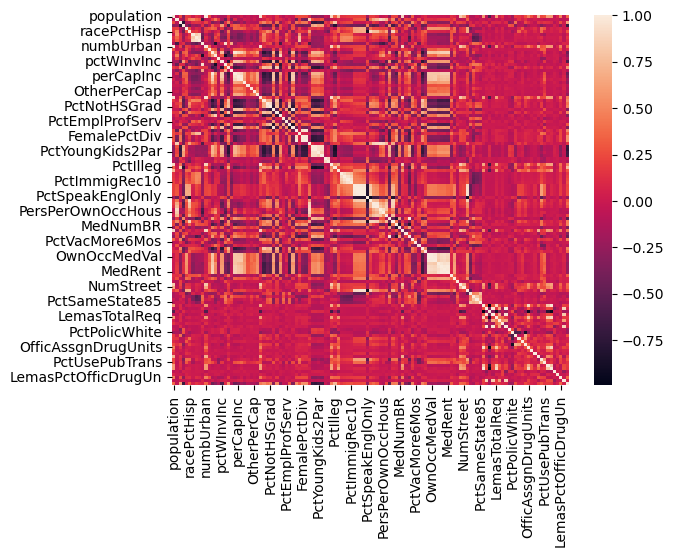

In [57]:
ax = sns.heatmap(df_imputed.corr())

### (d) Calculate the Coefficient of Variation CV

In [58]:
coeff = df_imputed.describe().loc["std"] / df_imputed.describe().loc["mean"]
display(coeff)

population             2.203503
householdsize          0.353298
racepctblack           1.410920
racePctWhite           0.323782
racePctAsian           1.359162
                         ...   
LemasPctPolicOnPatr    0.122331
LemasGangUnitDeploy    0.368040
LemasPctOfficDrugUn    2.555266
PolicBudgPerPop        0.337281
ViolentCrimesPerPop    0.979015
Length: 123, dtype: float64

### (e) Scatter plots and box plots for highest CV features

In [59]:
x = math.floor(math.sqrt(128))
x
l_sig = (coeff.sort_values(ascending=False).head(x))
l_sig_features = l_sig.index.tolist()
lsig_values = l_sig.values.tolist()
l_sig_features, lsig_values

(['NumStreet',
  'NumInShelters',
  'NumIlleg',
  'NumImmig',
  'LemasPctOfficDrugUn',
  'NumUnderPov',
  'population',
  'numbUrban',
  'HousVacant',
  'LandArea',
  'racePctHisp'],
 [4.407702440863979,
  3.4854812687233405,
  2.9941964494843063,
  2.9004971638852743,
  2.555266002927139,
  2.3049697148522097,
  2.203502536390986,
  2.0017436381957654,
  1.958779729782106,
  1.6780314766044846,
  1.614277791710681])

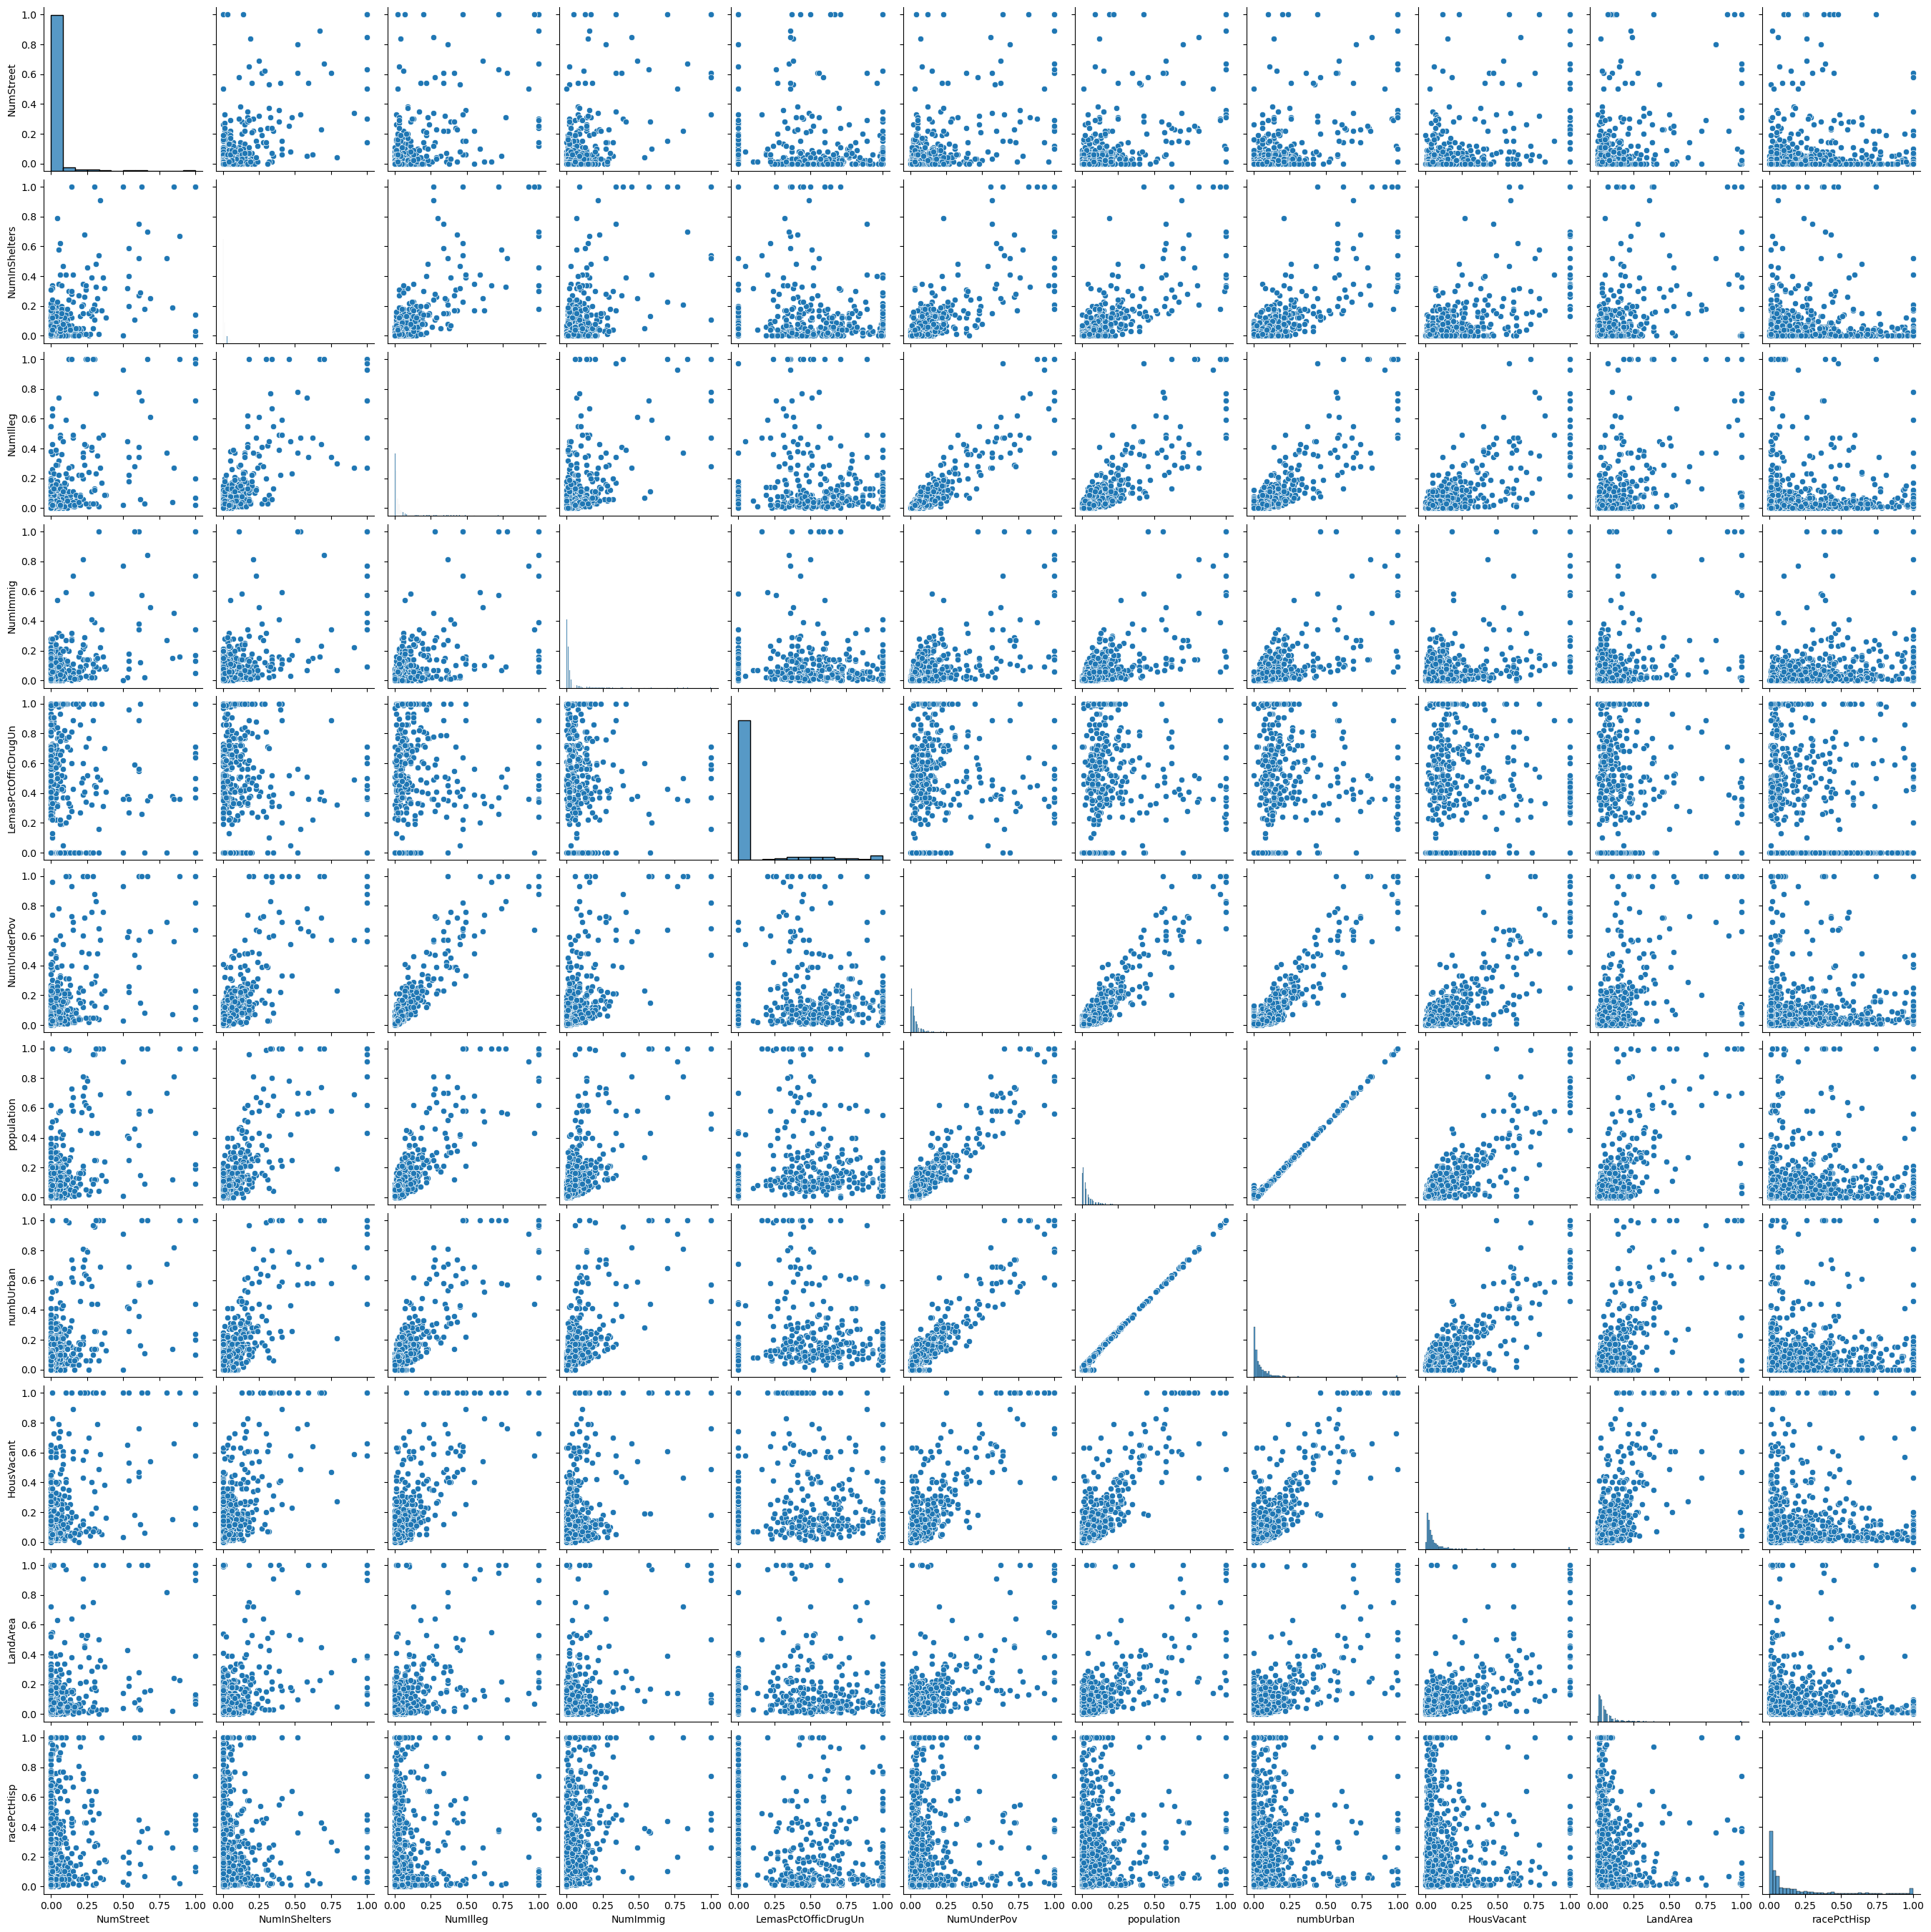

In [62]:
df2 = df_imputed[l_sig_features]
sns.pairplot(df2)
plt.show()

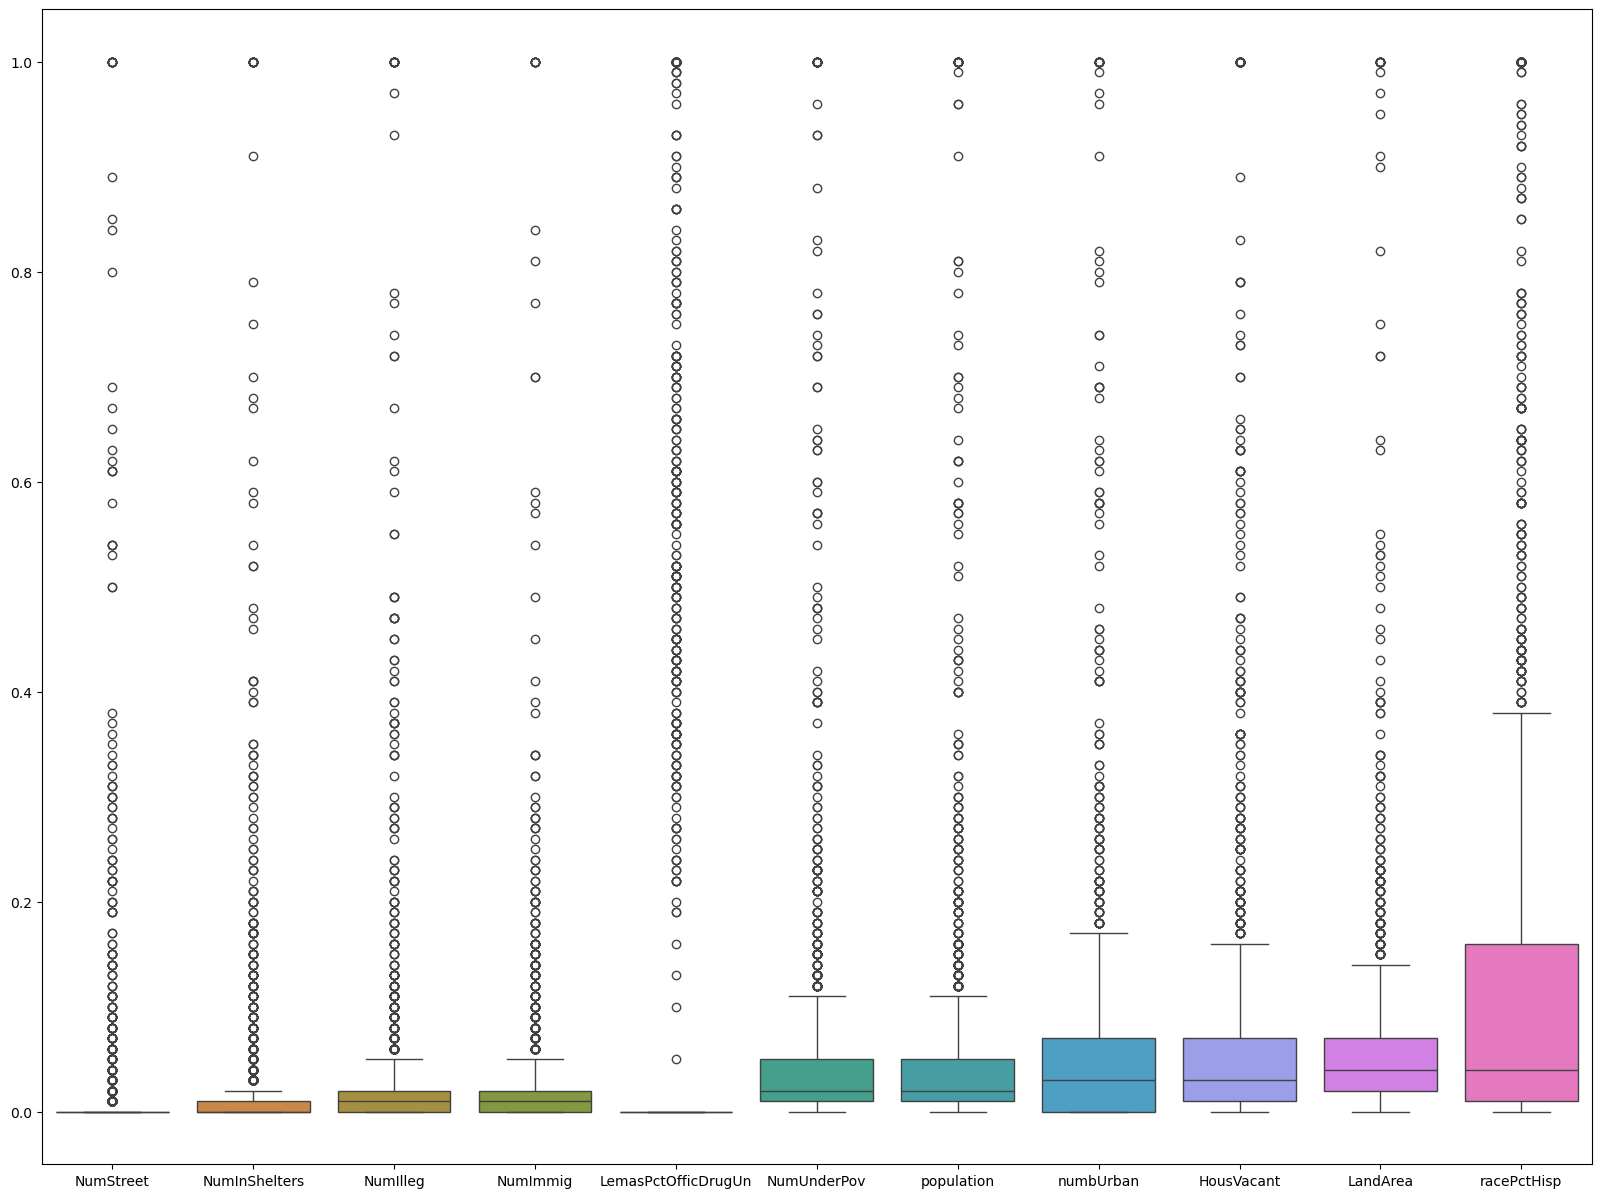

In [74]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df2)
plt.show()

From the above plots we can see that there is a very strong linear correlation between population and numUrban features and a linear correlation between NumUnderPov and population and numUrban. We can also see that the features' distributions are very skewed in the boxplot. We can also infer that a lot of NumStreet and LemasPctOfficeDrugUn values are 0, and that racePctHisp varies a lot. However, in my opinion, this isn't enough information to show which features are significant.

### (f) Fit a linear model

In [78]:
x_train = df_imputed_train.iloc[:, :-1]
y_train = df_imputed_train.iloc[:, -1:]
x_test = df_imputed_test.iloc[:, :-1]
y_test = df_imputed_test.iloc[:, -1:]
x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)
model = sm.OLS(y_train, x_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     ViolentCrimesPerPop   R-squared:                       0.711
Model:                             OLS   Adj. R-squared:                  0.686
Method:                  Least Squares   F-statistic:                     27.94
Date:                 Thu, 26 Mar 2026   Prob (F-statistic):          6.56e-291
Time:                         15:47:17   Log-Likelihood:                 955.40
No. Observations:                 1495   AIC:                            -1667.
Df Residuals:                     1373   BIC:                            -1019.
Df Model:                          121                                         
Covariance Type:             nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.4544      0.904      0.503      0.615      -1.319       2.228
population               -0.0199      0.477     -0.042      0.967      -0.955       0.916
householdsize            -0.0157      0.098     -0.161      0.872      -0.207       0.176
racepctblack              0.2848      0.060      4.754      0.000       0.167       0.402
racePctWhite              0.0106      0.067      0.159      0.874      -0.120       0.141
racePctAsian             -0.0278      0.041     -0.670      0.503      -0.109       0.054
racePctHisp               0.0180      0.065      0.275      0.784      -0.110       0.146
agePct12t21               0.1792      0.129      1.387      0.166      -0.074       0.433
agePct12t29              -0.3451      0.186     -1.858      0.063      -0.709       0.019
agePct16t24              -0.1237      0.198     -0.626      0.531      -0.511       0.264
agePct65up                0.0597      0.124      0.481      0.630      -0.184       0.303
numbUrban                -0.1260      0.465     -0.271      0.786      -1.038       0.786
pctUrban                  0.0484      0.019      2.581      0.010       0.012       0.085
medIncome                -0.1784      0.202     -0.881      0.378      -0.575       0.219
pctWWage                 -0.1399      0.107     -1.309      0.191      -0.350       0.070
pctWFarmSelf              0.0460      0.023      1.960      0.050   -3.35e-05       0.092
pctWInvInc               -0.2031      0.081     -2.505      0.012      -0.362      -0.044
pctWSocSec                0.1368      0.125      1.092      0.275      -0.109       0.383
pctWPubAsst               0.0601      0.054      1.109      0.268      -0.046       0.166
pctWRetire               -0.1249      0.045     -2.802      0.005      -0.212      -0.037
medFamInc                 0.3049      0.189      1.617      0.106      -0.065       0.675
perCapInc                -0.0485      0.222     -0.219      0.827      -0.484       0.387
whitePerCap              -0.1923      0.179     -1.072      0.284      -0.544       0.160
blackPerCap              -0.0401      0.030     -1.358      0.175      -0.098       0.018
indianPerCap             -0.0436      0.023     -1.911      0.056      -0.088       0.001
AsianPerCap               0.0301      0.022      1.381      0.168      -0.013       0.073
OtherPerCap               0.0304      0.022      1.364      0.173      -0.013       0.074
HispPerCap                0.0330      0.029      1.150      0.250      -0.023       0.089
NumUnderPov               0.0737      0.192      0.383      0.702      -0.303       0.451
PctPopUnderPov           -0.2035      0.074     -2.736      0.006      -0.349      -0.058
PctLess9thGrade          -0.0584      0.079     -0.743      0.457      -0.213       0.096
PctNotHSGrad

In [81]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)

MSE:  0.018112462026533452


### (g) Fit a ridge regression model

In [103]:
x_train = df_imputed_train.iloc[:, :-1]
y_train = df_imputed_train.iloc[:, -1:]
x_test = df_imputed_test.iloc[:, :-1]
y_test = df_imputed_test.iloc[:, -1:]
clf = RidgeCV(alphas=[0.0001, 0.001, 0.1, 1.0, 10.0, 100.0], cv=5)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)
print("Best alpha: ", clf.alpha_)

MSE:  0.017723737122827782
Best alpha:  1.0


### (h) Fit a LASSO model

In [108]:
x_train = df_imputed_train.iloc[:, :-1]
y_train = df_imputed_train.iloc[:, -1:].values
x_test = df_imputed_test.iloc[:, :-1]
y_test = df_imputed_test.iloc[:, -1:].values
reg = LassoCV(cv=5).fit(x_train, y_train)
y_pred = reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)
print("Best alpha: ", reg.alpha_)
coef = reg.coef_
print(list(df_imputed.columns[:-1][coef != 0]))
print(len(list(df_imputed.columns[:-1][coef != 0])))

ss = StandardScaler()
x_train_scaled = pd.DataFrame(ss.fit_transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(ss.fit_transform(x_test), columns=x_test.columns)
reg = LassoCV(cv=5).fit(x_train_scaled, y_train)
y_pred_scaled = reg.predict(x_test_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)
print("MSE: ", mse)
print("Best alpha: ", reg.alpha_)
coef = reg.coef_
print(list(df_imputed.columns[:-1][coef != 0]))
print(len(list(df_imputed.columns[:-1][coef != 0])))

MSE:  0.017735383043771757
Best alpha:  0.0001161472362682987
['racepctblack', 'racePctAsian', 'agePct12t21', 'agePct12t29', 'pctUrban', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'PctPopUnderPov', 'PctLess9thGrade', 'PctEmploy', 'PctEmplManu', 'PctOccupManu', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRec10', 'PctRecImmig10', 'PctNotSpeakEnglWell', 'PctLargHouseOccup', 'PersPerOccupHous', 'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup', 'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt', 'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 'RentLowQ', 'MedRent', 'MedRentPctHousInc', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet', 'PctForeignBorn', 'PctBornSam

### (i) Fit a PCR model

In [112]:
parameters = {'pca__n_components': np.arange(1,x_train.shape[1] +1)}
pcr_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA() ), ('linear_regression', LinearRegression(fit_intercept = True))])
pcr = GridSearchCV(pcr_pipe, parameters, scoring = 'neg_mean_squared_error', cv=5)
pcr.fit(x_train, y_train)
print(pcr.best_estimator_)
print("Best M:", pcr.best_params_)
y_pred_pcr = pcr.predict(x_test)
mse = mean_squared_error(y_test, y_pred_pcr)
print("MSE: ", mse)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=95)),
                ('linear_regression', LinearRegression())])
Best M: {'pca__n_components': 95}
MSE:  0.018338438679658647


In [113]:
model = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=pcr.best_params_['pca__n_components']) ), ('linear_regression', LinearRegression(fit_intercept = True))])
model.fit(x_train, y_train)
y_pred_pcr2 = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred_pcr2)
print("MSE: ", mse)


MSE:  0.018338438679658647


### (j) Fit a boosting tree

In [117]:
alpha = np.logspace(-3, 2, 10)
xgb = XGBRegressor()
grid = GridSearchCV(estimator=xgb, param_grid={'reg_alpha': alpha}, scoring='neg_mean_squared_error', cv=5)
grid.fit(x_train, y_train)
print("Best alpha: ", grid.best_params_['reg_alpha'])
y_pred_xgb = grid.predict(x_test)
mse = mean_squared_error(y_test, y_pred_xgb)
print("MSE: ", mse)

Best alpha:  2.1544346900318843
MSE:  0.018124028006587332


### REFERENCES

https://stackoverflow.com/questions/73948109/pandas-read-csv-file-error-unicodedecodeerror-utf-8-codec-cant-decode-byte-0

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html

https://github.com/christianversloot/machine-learning-articles/blob/main/building-a-decision-tree-for-classification-with-python-and-scikit-learn.md

https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html

https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

https://www.geeksforgeeks.org/machine-learning/how-to-choose-a-in-cost-complexity-pruning/

https://scikit-learn.org/stable/modules/impute.html

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html

### AI Prompts

Basic code fixing and cleanup

How to run cross validation

What does it mean when a feature has large coefficient of variance and does it affect how significant it is?

Ridge vs Lasso

PCR model